In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e7')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e7


In [2]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
)

print(train.shape)
print(test.shape)
print(sample_submission.shape)

(690088, 15)
(295753, 14)
(295753, 2)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

1

In [4]:
# =====================================================
# Feature Engineering
# =====================================================

# 1. Step Count
train['low_steps'] = (train['step_count'] < 6000).astype(int)
test['low_steps'] = (test['step_count'] < 6000).astype(int)


# 2. Exercise Duration
train['low_exercise'] = (train['exercise_duration'] < 30).astype(int)
test['low_exercise'] = (test['exercise_duration'] < 30).astype(int)


# 3. BMI threshold
train['bmi_over25'] = (train['bmi'] >= 25).astype(int)
test['bmi_over25'] = (test['bmi'] >= 25).astype(int)

train['bmi_over30'] = (train['bmi'] >= 30).astype(int)
test['bmi_over30'] = (test['bmi'] >= 30).astype(int)


# 4. 낮은 운동량 조합
train['low_activity_combo'] = (
    (train['exercise_duration'] < 30) &
    (train['step_count'] < 6000)
).astype(int)

test['low_activity_combo'] = (
    (test['exercise_duration'] < 30) &
    (test['step_count'] < 6000)
).astype(int)

1

In [5]:
TARGET = 'health_condition'

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()

X_test = test.copy()

In [6]:
drop_cols = []

if 'id' in X.columns:
    drop_cols.append('id')

X = X.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y shape:", y.shape)

X shape: (690088, 18)
X_test shape: (295753, 18)
y shape: (690088,)


In [7]:
numeric_cols = X.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numeric features:")
print(numeric_cols)

print("\nCategorical features:")
print(categorical_cols)

Numeric features:
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'low_steps', 'low_exercise', 'bmi_over25', 'bmi_over30', 'low_activity_combo']

Categorical features:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [8]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

print("\n전체 target 비율")
print(y.value_counts(normalize=True))

print("\nTrain target 비율")
print(y_train.value_counts(normalize=True))

print("\nValid target 비율")
print(y_valid.value_counts(normalize=True))

Train: (552070, 18)
Valid: (138018, 18)

전체 target 비율
health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

Train target 비율
health_condition
at-risk      0.858676
unhealthy    0.083647
fit          0.057677
Name: proportion, dtype: float64

Valid target 비율
health_condition
at-risk      0.858671
unhealthy    0.083649
fit          0.057681
Name: proportion, dtype: float64


In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

In [11]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf)
    ]
)

In [12]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake', 'low_steps',
                                                   'low_exercise', 'bmi_over25',
                                                   'bmi_over30',
                                                   'low_activity_combo']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['diet_type', 'stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol',
                                                   'gender'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [13]:
valid_pred = model.predict(X_valid)

In [14]:
balanced_acc = balanced_accuracy_score(
    y_valid,
    valid_pred
)

accuracy = accuracy_score(
    y_valid,
    valid_pred
)

print(f"Accuracy          : {accuracy:.5f}")
print(f"Balanced Accuracy : {balanced_acc:.5f}")

Accuracy          : 0.96474
Balanced Accuracy : 0.85135


In [15]:
print(
    classification_report(
        y_valid,
        valid_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

     at-risk     0.9647    0.9957    0.9800    118512
         fit     0.9487    0.7940    0.8645      7961
   unhealthy     0.9774    0.7643    0.8578     11545

    accuracy                         0.9647    138018
   macro avg     0.9636    0.8513    0.9008    138018
weighted avg     0.9648    0.9647    0.9631    138018



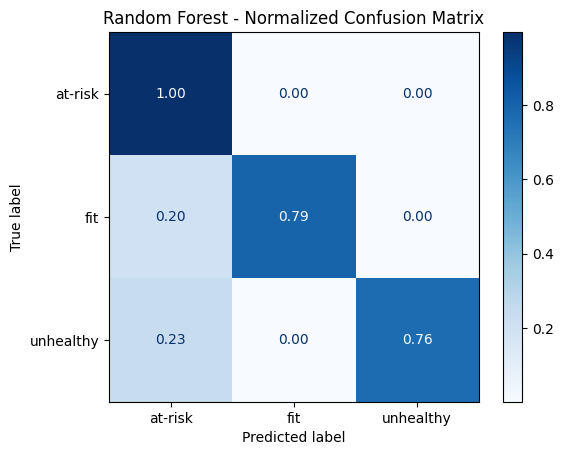

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_pred,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)

plt.title('Random Forest - Normalized Confusion Matrix')
plt.show()

In [17]:
feature_names = (
    model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    model
    .named_steps['classifier']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

display(feature_importance.head(30))

,feature,importance
0,num__sleep_duration,0.294207
15,cat__stress_level_high,0.131155
16,cat__stress_level_low,0.117455
21,cat__physical_activity_level_active,0.078469
17,cat__stress_level_medium,0.056259
2,num__bmi,0.051054
4,num__step_count,0.040301
5,num__exercise_duration,0.038645
3,num__calorie_expenditure,0.027746
1,num__heart_rate,0.027111


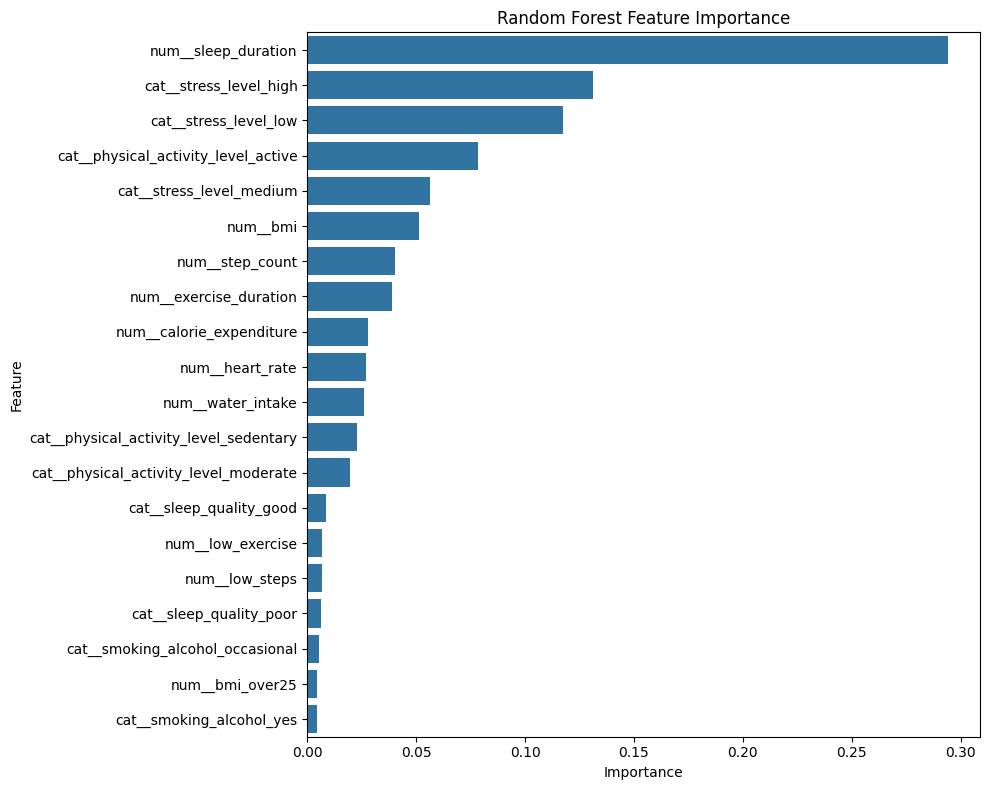

In [18]:
top_n = 20

top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

ㅇ

In [19]:
model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake', 'low_steps',
                                                   'low_exercise', 'bmi_over25',
                                                   'bmi_over30',
                                                   'low_activity_combo']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['diet_type', 'stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol',
                                                   'gender'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [20]:
test_pred = model.predict(X_test)

In [21]:
pd.Series(test_pred).value_counts(normalize=True)

at-risk      0.888694
unhealthy    0.064270
fit          0.047036
Name: proportion, dtype: float64

In [22]:
submission = sample_submission.copy()

submission[TARGET] = test_pred

submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [23]:
print(submission.shape)
print(submission[TARGET].value_counts())

(295753, 2)
health_condition
at-risk      262834
unhealthy     19008
fit           13911
Name: count, dtype: int64


In [24]:
submission.to_csv(
    'submission_randomforest_baseline.csv',
    index=False
)

ㄴ

In [25]:
experiment_results = pd.DataFrame(
    columns=[
        'experiment',
        'balanced_accuracy',
        'notes'
    ]
)

experiment_results.loc[len(experiment_results)] = [
    'RF Baseline',
    balanced_acc,
    'Original features + imputation + onehot + balanced_subsample'
]

experiment_results

,experiment,balanced_accuracy,notes
0,RF Baseline,0.851347,Original features + imputation + onehot + bala...
